In [1]:
from scipy.ndimage import gaussian_filter
from scipy.signal import filtfilt, butter
import numpy as np

b, a = butter(6, 0.4)

def calc_multi_velocity(vel, vel_nyq, slices, nsave=5):
    allrays, ngate = vel.shape
    vel_dualprfs = np.full((allrays, ngate, nsave), np.nan)

    ### pre create n array
    NN = np.arange(-2, 3)

    for sweep_slice in slices:
        vel_sweep     = vel[sweep_slice]
        vel_nyq_sweep = vel_nyq[sweep_slice]

        nray, ngate = vel_sweep.shape

        vel_dualprfs_sweep = np.full((nray, ngate, nsave), np.nan)

        for iray in range(nray):
            vel_ray_left,     vel_ray     = vel_sweep[iray-1],     vel_sweep[iray]
            vel_nyq_ray_left, vel_nyq_ray = vel_nyq_sweep[iray-1], vel_nyq_sweep[iray]

            ## skip this ray if it's all masked
            if vel_ray.mask.all(): continue

            if iray == nray-1:
                vel_ray_right = vel_sweep[0]
                vel_nyq_ray_right = vel_nyq_sweep[0]
            else:
                vel_ray_right = vel_sweep[iray+1]
                vel_nyq_ray_right = vel_nyq_sweep[iray+1]

            if vel_nyq_ray_left  == vel_nyq_ray and \
               vel_nyq_ray_right == vel_nyq_ray:
                continue

            for igate in range(ngate):
                if not vel_ray.mask[igate]:
                    v1 = vel_ray[igate] + 2 * NN * vel_nyq_ray
                    if not vel_ray_left.mask[igate] and vel_nyq_ray != vel_nyq_ray_left:                       
                        v2 = vel_ray_left[igate] + 2 * NN * vel_nyq_ray_left
                    elif not vel_ray_right.mask[igate] and vel_nyq_ray != vel_nyq_ray_right:
                        v2 = vel_ray_right[igate] + 2 * NN * vel_nyq_ray_right
                    else:
                        continue
                else:
                    continue

                vdiff = np.abs(np.subtract.outer(v1, v2))
                ind   = np.unravel_index(np.argsort(vdiff, axis=None), vdiff.shape)

                vel_dualprfs_sweep[iray, igate] = v1[ ind[0][:nsave] ]

        vel_dualprfs[sweep_slice] = vel_dualprfs_sweep

    return np.ma.masked_invalid(vel_dualprfs)


def normalized_gaussian_filter(data, nomask, sigma=1):
    filter  = gaussian_filter(data * nomask, sigma=sigma, mode=('wrap', 'reflect'))
    weights = gaussian_filter(nomask, sigma=sigma, mode=('wrap', 'reflect'))

    filter  = np.where(
        nomask == 1,
        filter / weights,
        np.nan
    )

    return filter

def find_nyquist_velocity(vel, dual_prf_vel_nyq, prt_ratio):
    nray = vel.shape[0]
    vel_nyq = np.zeros(nray)

    prf_ratio_h = int(prt_ratio / (1 - prt_ratio))
    prf_ratio_l = prf_ratio_h + 1

    vel_nyq_h   = dual_prf_vel_nyq / prf_ratio_h
    vel_nyq_l   = dual_prf_vel_nyq / prf_ratio_l

    vel_max = np.ma.max(np.ma.abs(vel), axis=1)
    idx     = np.argmin((np.abs(vel_max - vel_nyq_h), np.abs(vel_max - vel_nyq_l)), axis=0)
    vel_nyq[ idx == 0 ] = vel_nyq_h
    vel_nyq[ idx == 1 ] = vel_nyq_l

    return vel_nyq

def smooth(vel, vel_nyq):
    vel_smth = vel.copy()
    nray  = vel_nyq.size

    for iray in range(nray):
        _good = ~vel[iray].mask
        if np.count_nonzero(_good) <= 21: continue

        vel_good, nyquist_velocity = vel[iray, _good], vel_nyq[iray]

        f = np.exp(1j * np.pi * vel_good / nyquist_velocity)
        #f = filtfilt(b, a, f)

        vel_smth[iray, _good] = np.angle(f) * nyquist_velocity / np.pi

    return vel_smth

def smooth2D(vel, nyquist_velocity, slices, sigma=1.8):
    vel_smooth = vel.copy()
    phase =  np.pi * vel / nyquist_velocity

    for slice in slices:
        phase_slice = phase[slice].copy()

        complex_slice = np.ma.exp(1j * phase_slice).filled(0)
        nomask = (~phase_slice.mask).astype(float)

        complex_slice = normalized_gaussian_filter(
            complex_slice,
            nomask,
            sigma=sigma
        )

        phase_filter = np.ma.masked_invalid(np.angle(complex_slice))

        vel_smooth[slice] = phase_filter * nyquist_velocity / np.pi

    return vel_smooth

def custom_round(data, factor=0.25):
    data[ data >  factor ] -= factor
    data[ data < -factor ] += factor

    return np.round(data)

def correct(vel, vel_smooth, vel_nyq, slices, factor=0.1):
    vel_correct = vel.copy()

    for slice in slices:
        vel_slice, vel_smooth_slice, vel_nyq_slice = vel[slice], vel_smooth[slice], vel_nyq[slice].reshape((-1,1))

        nn = custom_round((vel_smooth_slice - vel_slice) / (2 * vel_nyq_slice), factor=factor)

        vel_correct[slice] += 2 * nn *  vel_nyq_slice

    return vel_correct



In [2]:
import pyart

#radar = pyart.io.read_cfradial('sample_data/KUNIMI_20240828_140000_EL002_V10.nc')
#radar = pyart.io.read_cfradial('sample_data/FURUTSUKI_20240829_050100_EL001_V10.nc')
radar = pyart.io.read_cfradial('sample_data/SAKURAJIMA_20240828_135100_EL001_V10.nc')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [3]:
### get nyquist velocity
nyquist_velocity = radar.instrument_parameters['nyquist_velocity']['data']

velocity = radar.fields['V']['data'].copy()

### get prt ratio
prt_ratio = radar.instrument_parameters['prt_ratio']['data']

### compute nyquist_velocity in each ray, not dual prf nyquist_velocity
#nyquist_velocity_ray = find_nyquist_velocity(velocity, nyquist_velocity[0], prt_ratio[0])
nyquist_velocity_ray = radar.instrument_parameters['nyquist_velocity']['data']

### smooth data for X band
velocity = smooth(velocity, nyquist_velocity_ray)

slices = list(radar.iter_slice())
#velocity_dualprf = calc_dualprf_velocity(velocity, nyquist_velocity_ray, slices)
velocity_dualprfs  = calc_multi_velocity(velocity, nyquist_velocity_ray, slices)
velocity_dualprf   = velocity_dualprfs[..., 0]

radar.add_field_like('V', 'V_dualprf', velocity_dualprf)
radar.add_field_like('V', 'V_dualprf1', velocity_dualprfs[..., 1])
radar.add_field_like('V', 'V_dualprf2', velocity_dualprfs[..., 2])

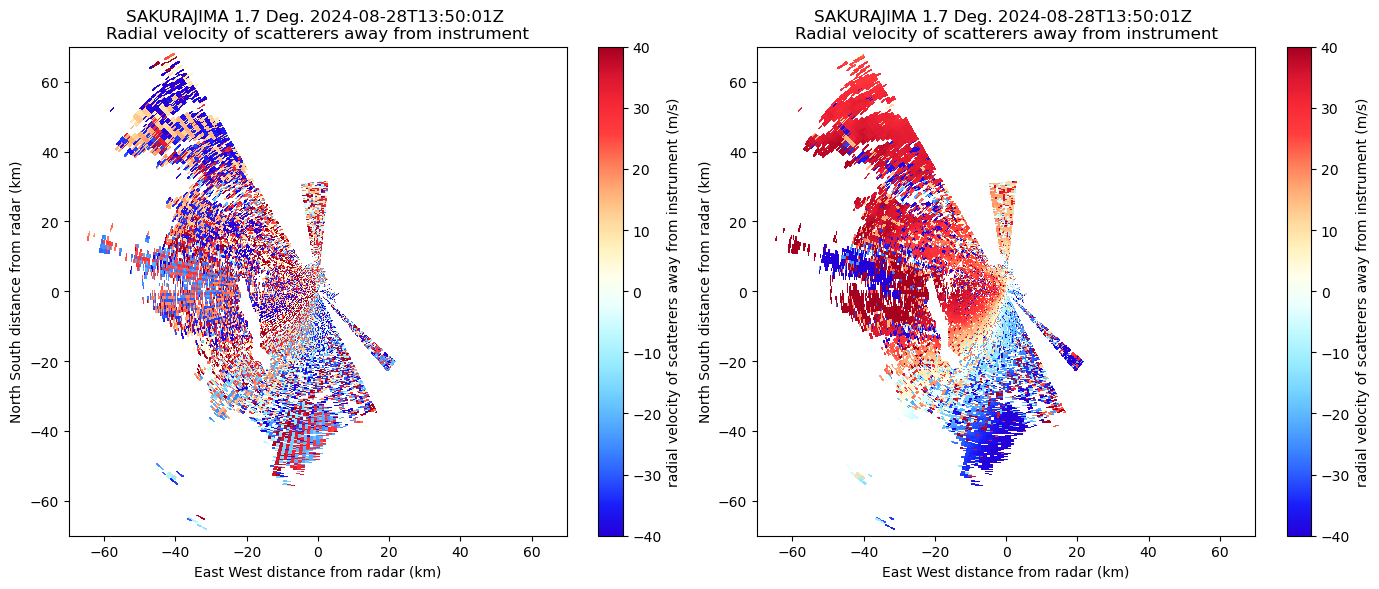

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14,6), tight_layout=True)
gs = gridspec.GridSpec(1, 2)

display = pyart.graph.RadarDisplay(radar)

## 2d plot
ax1 = fig.add_subplot(gs[0, 0])
display.set_limits((-70, 70), (-70, 70), ax=ax1)
display.plot_ppi('V_dualprf1', 0, cmap="pyart_BuDRd18", vmin=-40, vmax=40, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
display.set_limits((-70, 70), (-70, 70), ax=ax2)
display.plot_ppi('V_dualprf', 0, cmap="pyart_BuDRd18", vmin=-40, vmax=40, ax=ax2)

In [ ]:

vel_nyq_h, vel_nyq_l = nyquist_velocity.max(), nyquist_velocity.min()
R = int(vel_nyq_h / (vel_nyq_h - vel_nyq_l))
vel_nyq_common = R * vel_nyq_l

print(vel_nyq_common)

for ii in range(1, 3):
    if ii == 1:
        velocity_dualprf_new = velocity_dualprf

    #V_dualprf_smooth = smooth2D(velocity_dualprf_new, radar.instrument_parameters['nyquist_velocity']['data'][0], slices,)
    V_dualprf_smooth = smooth2D(velocity_dualprf_new, vel_nyq_common, slices,)


    for _ in range(5):
        V_dualprf_correct = correct(velocity_dualprf_new, V_dualprf_smooth, nyquist_velocity_ray, slices, factor=0.15)

        for _ in range(10):
            #V_dualprf_smooth = smooth2D(V_dualprf_correct, radar.instrument_parameters['nyquist_velocity']['data'][0], slices,)
            V_dualprf_smooth = smooth2D(V_dualprf_correct, vel_nyq_common, slices,)
            V_dualprf_correct = correct(V_dualprf_correct, V_dualprf_smooth, nyquist_velocity_ray, slices, factor=0.15)

    velocity_dualprf_new = np.ma.where(
        V_dualprf_correct != velocity_dualprf_new,
        velocity_dualprfs[..., ii],
        velocity_dualprf_new
    )
"""
for ii in range(1,5):
    if ii == 1:
        velocity_dualprf_new = velocity_dualprf
        
    V_dualprf_smooth = smooth2D(velocity_dualprf_new, radar.instrument_parameters['nyquist_velocity']['data'][0], slices,)
    velocity_dualprf_new = correct_with_velocity(velocity_dualprf_new, V_dualprf_smooth, velocity_dualprfs[..., ii], nyquist_velocity_ray, slices)

V_dualprf_smooth = smooth2D(velocity_dualprf_new, radar.instrument_parameters['nyquist_velocity']['data'][0], slices,)
velocity_dualprf_new = correct(velocity_dualprf_new, V_dualprf_smooth, nyquist_velocity_ray, slices)
"""

radar.add_field_like('V', 'V_dualprf_correct', V_dualprf_correct, replace_existing=True)
radar.add_field_like('V', 'V_dualprf_new', velocity_dualprf_new, replace_existing=True)

46.05


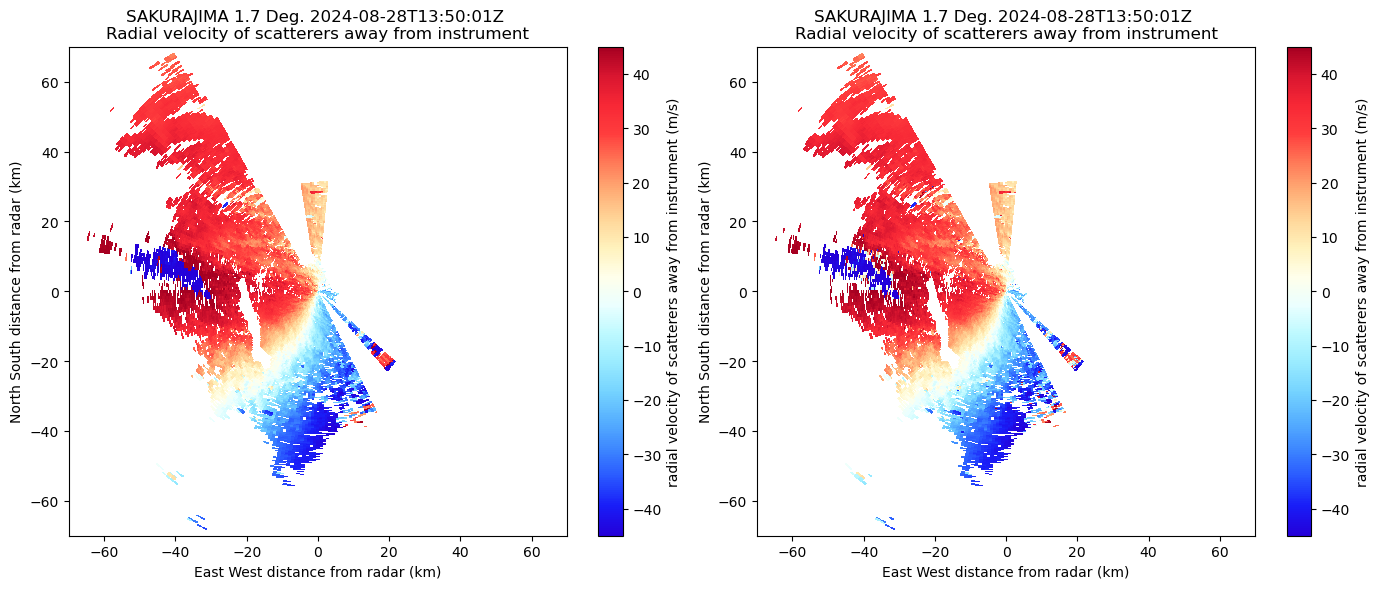

In [6]:
fig = plt.figure(figsize=(14,6), tight_layout=True)
gs = gridspec.GridSpec(1, 2)

display = pyart.graph.RadarDisplay(radar)

## 2d plot
ax1 = fig.add_subplot(gs[0, 0])
display.set_limits((-70, 70), (-70, 70), ax=ax1)
display.plot_ppi('V_dualprf_correct', 0, cmap="pyart_BuDRd18", vmin=-45, vmax=45, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
display.set_limits((-70, 70), (-70, 70), ax=ax2)
display.plot_ppi('V_dualprf_new', 0, cmap="pyart_BuDRd18", vmin=-45, vmax=45, ax=ax2)

In [7]:
correct_V = pyart.correct.dealias_region_based(
    radar, 
    nyquist_vel=vel_nyq_common, 
    vel_field='V_dualprf_correct', 
    rays_wrap_around=True, 
    interval_splits=7
)

radar.add_field('correct_V', correct_V, replace_existing=True)

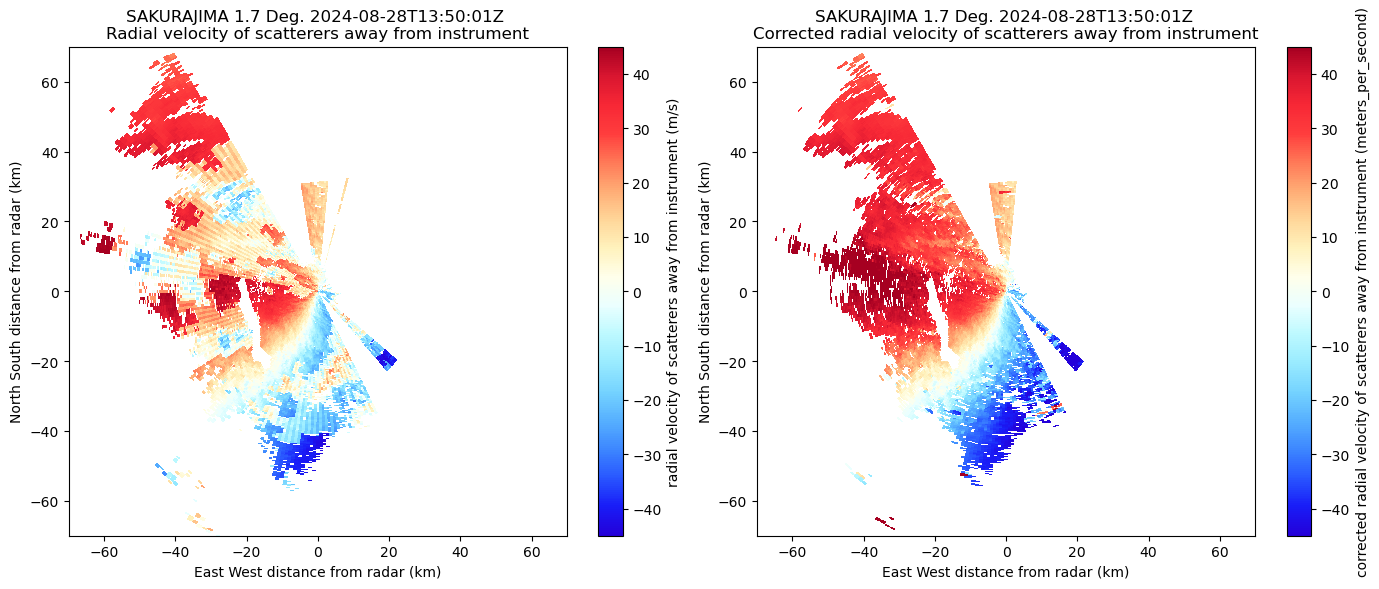

In [8]:
fig = plt.figure(figsize=(14,6), tight_layout=True)
gs = gridspec.GridSpec(1, 2)

display = pyart.graph.RadarDisplay(radar)

## 2d plot
ax1 = fig.add_subplot(gs[0, 0])
display.set_limits((-70, 70), (-70, 70), ax=ax1)
display.plot_ppi('V', 0, cmap="pyart_BuDRd18", vmin=-45, vmax=45, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
display.set_limits((-70, 70), (-70, 70), ax=ax2)
display.plot_ppi('correct_V', 0, cmap="pyart_BuDRd18", vmin=-45, vmax=45, ax=ax2)